# Apriori Experiment Notebook

Notebook ini untuk eksperimen parameter Apriori (support/confidence/lift), evaluasi rule, dan plotting hasil.


In [1]:
from pathlib import Path
import sys
import csv
from itertools import product
from time import perf_counter
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "apriori.py").exists():
            return p
    raise FileNotFoundError("Tidak menemukan project root (apriori.py).")

ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from apriori import apriori, load_transactions_from_csv, load_transactions_from_csv_multi

print("Project root:", ROOT)


Project root: /home/marison/koding/algoritma-apriori


## 1) Pilih Dataset

- Default menggunakan `data/dataset_import_1000_transaksi.csv` dengan item gabungan `Jurusan + Buku` agar rule lebih bervariasi.
- Untuk data sederhana `sample_transactions.csv`, kosongkan `item_specs` dan pakai `item_col = "item"`.


In [2]:
DATA_PATH = ROOT / "data" / "dataset_import_1000_transaksi.csv"

# Opsi data sederhana:
# DATA_PATH = ROOT / "data" / "sample_transactions.csv"

transaction_id_col = "transaction_id"
item_col = "item"  # dipakai jika item_specs dikosongkan
item_specs = [
    ("department_code", "Jurusan"),
    ("book_title", "Buku"),
]

# Untuk sample_transactions.csv gunakan: item_specs = []

if item_specs:
    transactions = load_transactions_from_csv_multi(
        DATA_PATH,
        transaction_id_col=transaction_id_col,
        item_specs=item_specs,
    )
    item_description = ", ".join(
        f"{column}={prefix}" if prefix else column for column, prefix in item_specs
    )
else:
    transactions = load_transactions_from_csv(
        DATA_PATH,
        transaction_id_col=transaction_id_col,
        item_col=item_col,
    )
    item_description = item_col

print(f"Dataset: {DATA_PATH}")
print(f"Item config: {item_description}")
print(f"Jumlah transaksi: {len(transactions)}")


Dataset: /home/marison/koding/algoritma-apriori/data/dataset_import_1000_transaksi.csv
Item config: department_code=Jurusan, book_title=Buku
Jumlah transaksi: 1000


## 2) Jalankan Apriori (Single Run)


In [3]:
min_support = 0.02
min_confidence = 0.30
min_lift = 1.00

frequent_itemsets, rules = apriori(
    transactions=transactions,
    min_support=min_support,
    min_confidence=min_confidence,
    min_lift=min_lift,
)

print("Frequent itemsets:", len(frequent_itemsets))
print("Association rules:", len(rules))

top_n = 15
for i, r in enumerate(rules[:top_n], start=1):
    print(
        f"{i:02d}. IF {list(r.antecedent)} THEN {list(r.consequent)} "
        f"| support={r.support:.4f} confidence={r.confidence:.4f} lift={r.lift:.4f}"
    )


Frequent itemsets: 114
Association rules: 30
01. IF ['Buku:SQL Lanjutan', 'Jurusan:TE'] THEN ['Buku:AI Dasar'] | support=0.0230 confidence=0.3833 lift=1.5972
02. IF ['Buku:Basis Data Dasar', 'Buku:Python untuk Data'] THEN ['Jurusan:SI'] | support=0.0220 confidence=0.4151 lift=1.5489
03. IF ['Buku:Pemrograman Web', 'Jurusan:MI'] THEN ['Buku:Sistem Informasi Manajemen'] | support=0.0240 confidence=0.3750 lift=1.5244
04. IF ['Buku:Pemrograman Web', 'Buku:Python untuk Data'] THEN ['Jurusan:SI'] | support=0.0250 confidence=0.4032 lift=1.5046
05. IF ['Buku:Pemrograman Web', 'Buku:Sistem Informasi Manajemen'] THEN ['Jurusan:MI'] | support=0.0240 confidence=0.3636 lift=1.4964
06. IF ['Buku:Data Mining Konsep', 'Buku:Pemrograman Web'] THEN ['Jurusan:SI'] | support=0.0250 confidence=0.3906 lift=1.4576
07. IF ['Jurusan:MI'] THEN ['Buku:Sistem Informasi Manajemen'] | support=0.0860 confidence=0.3539 lift=1.4387
08. IF ['Buku:Sistem Informasi Manajemen'] THEN ['Jurusan:MI'] | support=0.0860 confide

## 3) Eksperimen Parameter (Grid Search)


In [4]:
supports = [0.01, 0.02, 0.03, 0.05]
confidences = [0.25, 0.30, 0.35, 0.40]
exp_min_lift = 1.0

results = []
for s, c in product(supports, confidences):
    t0 = perf_counter()
    exp_itemsets, exp_rules = apriori(
        transactions=transactions,
        min_support=s,
        min_confidence=c,
        min_lift=exp_min_lift,
    )
    runtime_ms = (perf_counter() - t0) * 1000
    row = {
        "frequent_itemsets_count": len(exp_itemsets),
        "min_support": s,
        "min_confidence": c,
        "rules_count": len(exp_rules),
        "max_lift": max((r.lift for r in exp_rules), default=0.0),
        "avg_lift": (sum(r.lift for r in exp_rules) / len(exp_rules)) if exp_rules else 0.0,
        "runtime_ms": runtime_ms,
    }
    results.append(row)

for r in results:
    print(
        f"s={r['min_support']:.2f}, c={r['min_confidence']:.2f} "
        f"-> rules={r['rules_count']}, max_lift={r['max_lift']:.4f}, runtime={r['runtime_ms']:.2f}ms"
    )


s=0.01, c=0.25 -> rules=283, max_lift=1.5972, runtime=67.32ms
s=0.01, c=0.30 -> rules=88, max_lift=1.5972, runtime=59.61ms
s=0.01, c=0.35 -> rules=19, max_lift=1.5972, runtime=56.38ms
s=0.01, c=0.40 -> rules=3, max_lift=1.5496, runtime=53.11ms
s=0.02, c=0.25 -> rules=86, max_lift=1.5972, runtime=30.68ms
s=0.02, c=0.30 -> rules=30, max_lift=1.5972, runtime=30.26ms
s=0.02, c=0.35 -> rules=12, max_lift=1.5972, runtime=31.60ms
s=0.02, c=0.40 -> rules=2, max_lift=1.5489, runtime=29.23ms
s=0.03, c=0.25 -> rules=45, max_lift=1.4387, runtime=29.09ms
s=0.03, c=0.30 -> rules=5, max_lift=1.4387, runtime=28.82ms
s=0.03, c=0.35 -> rules=1, max_lift=1.4387, runtime=28.61ms
s=0.03, c=0.40 -> rules=0, max_lift=0.0000, runtime=28.76ms
s=0.05, c=0.25 -> rules=45, max_lift=1.4387, runtime=24.55ms
s=0.05, c=0.30 -> rules=5, max_lift=1.4387, runtime=23.11ms
s=0.05, c=0.35 -> rules=1, max_lift=1.4387, runtime=23.09ms
s=0.05, c=0.40 -> rules=0, max_lift=0.0000, runtime=24.28ms


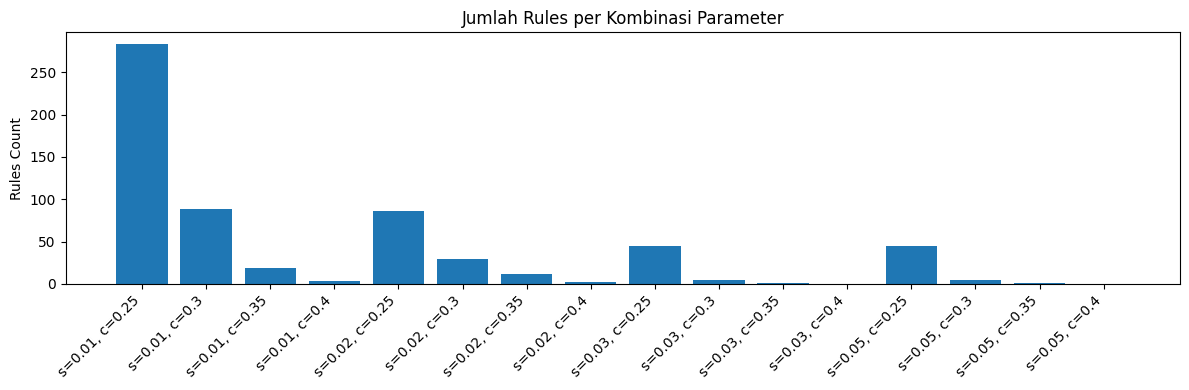

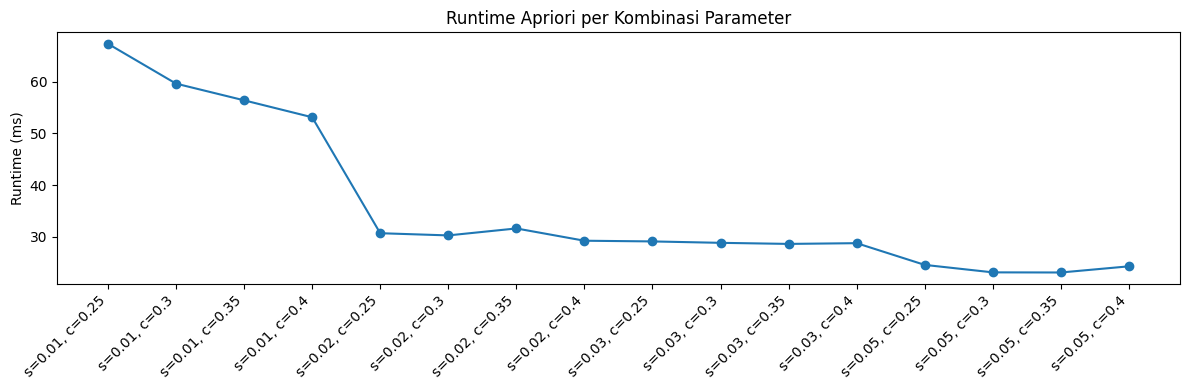

In [5]:
labels = [f"s={r['min_support']}, c={r['min_confidence']}" for r in results]
rules_count = [r["rules_count"] for r in results]
runtime_ms = [r["runtime_ms"] for r in results]

plt.figure(figsize=(12, 4))
plt.bar(labels, rules_count)
plt.xticks(rotation=45, ha="right")
plt.title("Jumlah Rules per Kombinasi Parameter")
plt.ylabel("Rules Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(labels, runtime_ms, marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Runtime Apriori per Kombinasi Parameter")
plt.ylabel("Runtime (ms)")
plt.tight_layout()
plt.show()


## 4) Simpan Ringkasan Eksperimen


In [6]:
out_dir = ROOT / "outputs" / "notebook_experiment"
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "experiment_summary.csv"

with out_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["frequent_itemsets_count", "min_support", "min_confidence", "rules_count", "max_lift", "avg_lift", "runtime_ms"],
    )
    writer.writeheader()
    writer.writerows(results)

print("Tersimpan:", out_csv)


Tersimpan: /home/marison/koding/algoritma-apriori/outputs/notebook_experiment/experiment_summary.csv
